# Peak detection and interpolation

This notebook illustrates the peak-detection process on a synthetic sound. It first computes and displays the magnitude spectrum of one analysis frame using `dftModel`, and then detects spectral peaks with `peakDetection` and refines them with `peakInterp`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy.signal import get_window
from smstools.models import dftModel as DFT
from smstools.models import utilFunctions as UF


## 1. Create a synthetic sound and display its magnitude spectrum

The example signal is a short sum of sinusoids with slightly non-integer frequencies, which makes the interpolation step easy to observe.

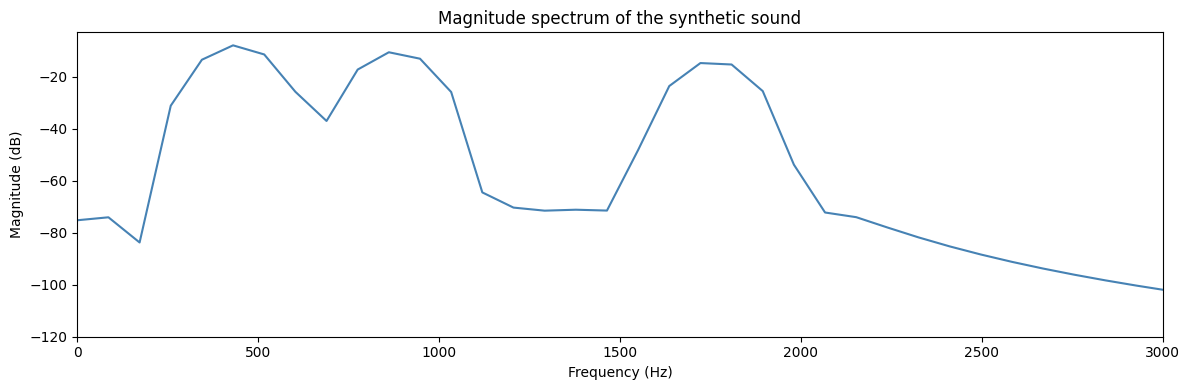

In [10]:
fs = 22050
M = 256
N = 256
t = -60
w = get_window('blackman', M)
n = np.arange(M)
original_freqs = np.array([440.0, 880.5, 1760.3])
amplitudes = np.array([0.8, 0.6, 0.4])
x = (amplitudes[0] * np.cos(2 * np.pi * original_freqs[0] * n / fs + 0.2)
     + amplitudes[1] * np.cos(2 * np.pi * original_freqs[1] * n / fs + 1.0)
     + amplitudes[2] * np.cos(2 * np.pi * original_freqs[2] * n / fs + 2.1))
mX, pX = DFT.dftAnal(x, w, N)
bin_freqs = np.arange(mX.size) * fs / float(N)
maxplotfreq = 3000
plt.figure(figsize=(12, 4))
plt.plot(bin_freqs, mX, color='steelblue', linewidth=1.5)
plt.xlim(0, maxplotfreq)
plt.ylim(-120, np.max(mX) + 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Magnitude spectrum of the synthetic sound')
plt.tight_layout()
plt.show()


## 2. Detect peaks and interpolate them

`peakDetection` returns discrete FFT-bin peak locations, so those frequency estimates are quantized by the bin spacing and can be slightly above or below the original sinusoid frequencies. `peakInterp` then refines those estimates to get much closer to the true frequencies.


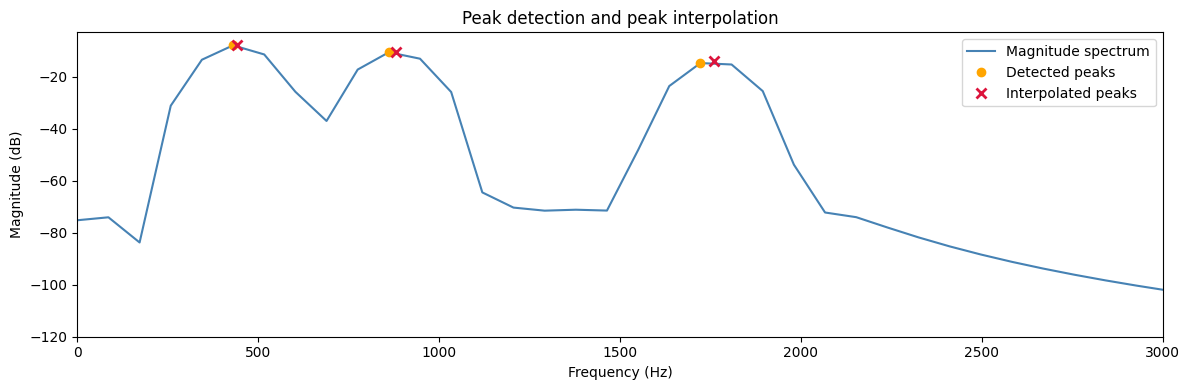

FFT bin spacing (Hz):
86.13
Original frequencies (Hz):
[ 440.   880.5 1760.3]
Detected peak frequencies (Hz):
[ 430.66  861.33 1722.66]
Interpolated peak frequencies (Hz):
[ 440.32  881.02 1760.61]


In [11]:
ploc = UF.peakDetection(mX, t)
iploc, ipmag, ipphase = UF.peakInterp(mX, pX, ploc)
peak_freqs = ploc * fs / float(N)
interp_freqs = iploc * fs / float(N)
plt.figure(figsize=(12, 4))
plt.plot(bin_freqs, mX, color='steelblue', linewidth=1.5, label='Magnitude spectrum')
plt.plot(peak_freqs, mX[ploc], 'o', color='orange', markersize=6, label='Detected peaks')
plt.plot(interp_freqs, ipmag, 'x', color='crimson', markersize=7, mew=2, label='Interpolated peaks')
plt.xlim(0, maxplotfreq)
plt.ylim(-120, np.max(mX) + 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Peak detection and peak interpolation')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print('FFT bin spacing (Hz):')
print(np.round(fs / float(N), 2))
print('Original frequencies (Hz):')
print(np.round(original_freqs, 2))
print('Detected peak frequencies (Hz):')
print(np.round(peak_freqs, 2))
print('Interpolated peak frequencies (Hz):')
print(np.round(interp_freqs, 2))


## 3. Synthesize the original, detected, and interpolated frequencies

This cell synthesizes three 1-second signals so you can compare the target sinusoidal frequencies with the discrete-bin peak estimates and the interpolated peak estimates.


In [12]:
duration = 1.0

def synthesize_sines(freqs, amplitudes, fs, duration):
    t = np.arange(int(fs * duration)) / fs
    y = np.zeros_like(t)
    for freq, amp in zip(freqs, amplitudes):
        y += amp * np.cos(2 * np.pi * freq * t)
    y /= np.max(np.abs(y))
    return y

original_tones = synthesize_sines(original_freqs, amplitudes, fs, duration)
detected_tones = synthesize_sines(peak_freqs, amplitudes, fs, duration)
interpolated_tones = synthesize_sines(interp_freqs, amplitudes, fs, duration)
print('Original frequencies:')
ipd.display(ipd.Audio(data=original_tones, rate=fs))
print('Detected peak frequencies:')
ipd.display(ipd.Audio(data=detected_tones, rate=fs))
print('Interpolated peak frequencies:')
ipd.display(ipd.Audio(data=interpolated_tones, rate=fs))


Original frequencies:


Detected peak frequencies:


Interpolated peak frequencies:
